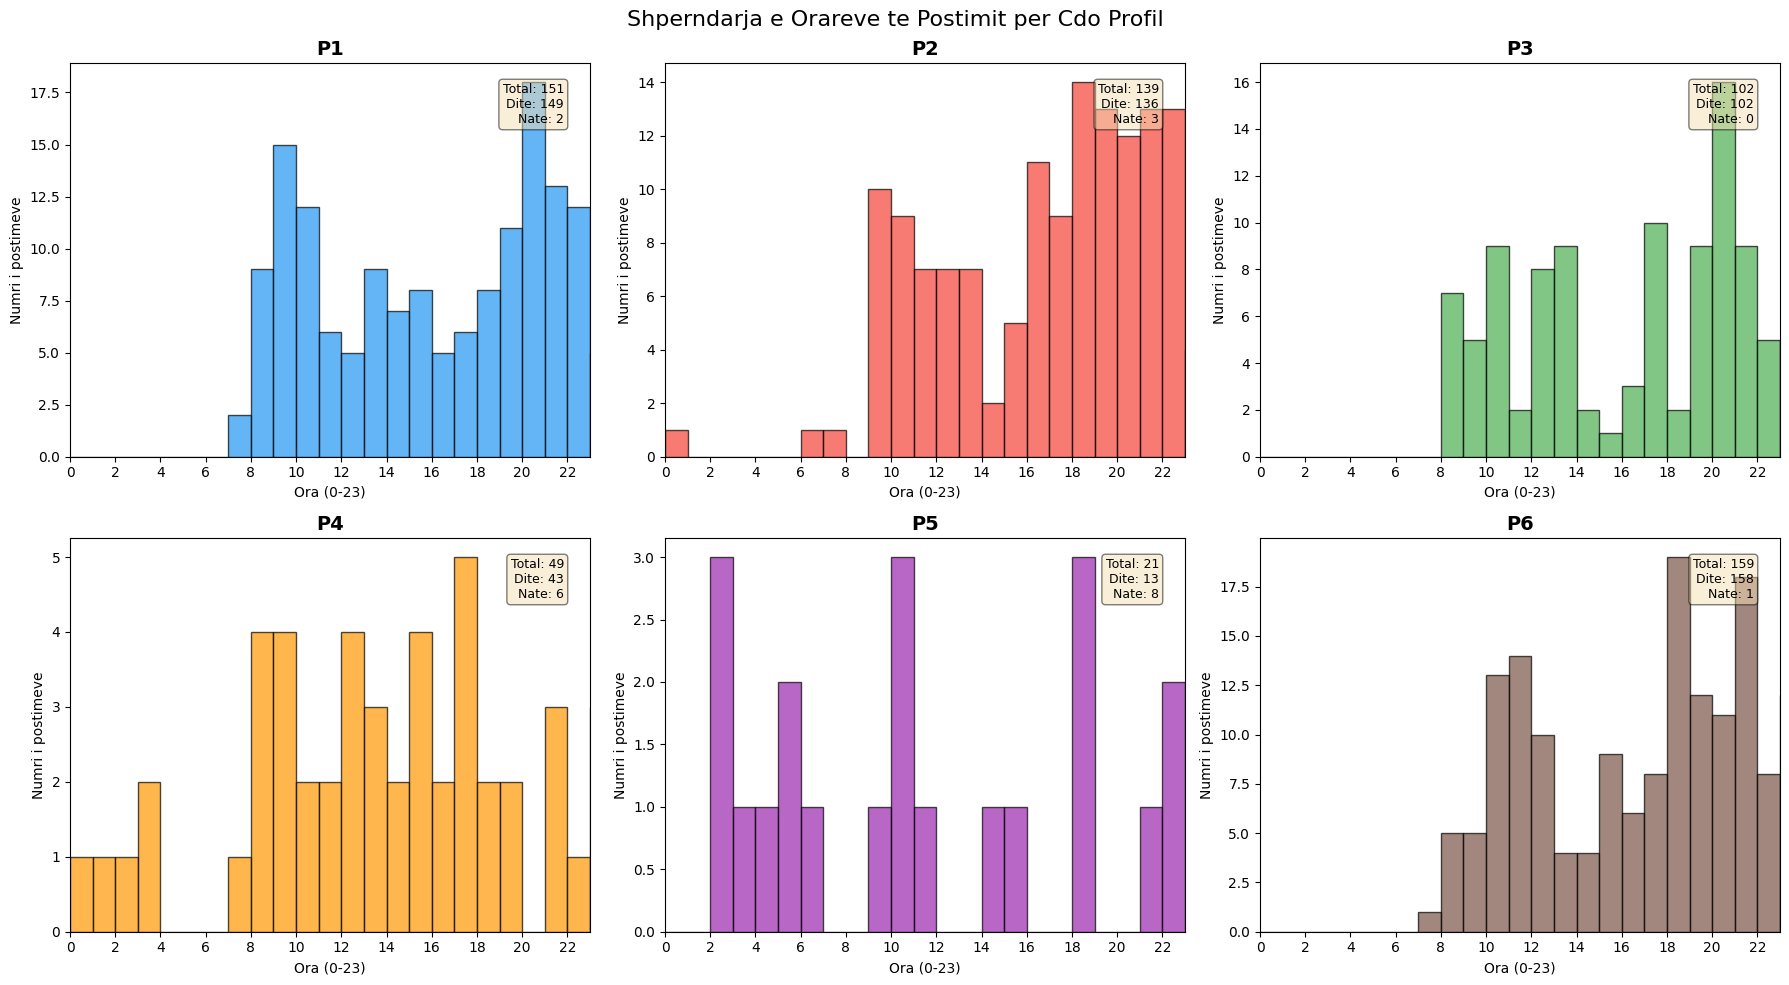

Figura e ruajtur ne folderin 'figurat'


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Rruga baze - ndrysho nese eshte ndryshe
base = r"C:\Users\Laura Biba\Desktop\OSINT Research\profile"

profiles = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Shperndarja e Orareve te Postimit per Cdo Profil', fontsize=16)

for i, profile in enumerate(profiles):
    ax = axes[i//3][i%3]
    path = os.path.join(base, profile, 'timestamps.csv')
    df = pd.read_csv(path)
    
    # Histogram i oreve
    ax.hist(df['hour'], bins=range(25), color=['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#795548'][i], 
            edgecolor='black', alpha=0.7)
    ax.set_title(f'{profile}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ora (0-23)')
    ax.set_ylabel('Numri i postimeve')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(0, 23)
    
    # Shenime statistikore
    total = len(df)
    night = len(df[df['hour'] < 8])
    day = total - night
    ax.text(0.95, 0.95, f'Total: {total}\nDite: {day}\nNate: {night}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(base, '..', 'figurat', 'V4_oraret_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Figura e ruajtur ne folderin 'figurat'")

In [5]:
import pandas as pd
import os

base = r"C:\Users\Laura Biba\Desktop\OSINT Research\profile"
profiles = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

results = []
for p in profiles:
    df = pd.read_csv(os.path.join(base, p, 'timestamps.csv'))
    total = len(df)
    night = len(df[df['hour'] < 8])
    day = total - night
    peak_hour = df['hour'].mode()[0]
    day_pct = round(day * 100 / total, 1)
    
    if day_pct > 90:
        timezone = "UTC+1 (i qarte)"
    elif day_pct > 75:
        timezone = "UTC+1 (i mundshem)"
    elif day_pct > 60:
        timezone = "I paqarte"
    else:
        timezone = "I painferencueshem"
    
    results.append({
        'Profil': p,
        'Total': total,
        'Dite (8-23)': day,
        'Nate (0-7)': night,
        'Dite %': day_pct,
        'Ora peak': peak_hour,
        'Timezone inferuar': timezone
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
df_results.to_csv(os.path.join(base, '..', 'rezultate', 'V4_timezone_analiza.csv'), index=False)
print("\nRezultati i ruajtur ne rezultate/V4_timezone_analiza.csv")

Profil  Total  Dite (8-23)  Nate (0-7)  Dite %  Ora peak  Timezone inferuar
    P1    151          149           2    98.7        20    UTC+1 (i qarte)
    P2    139          136           3    97.8        18    UTC+1 (i qarte)
    P3    102          102           0   100.0        20    UTC+1 (i qarte)
    P4     49           43           6    87.8        17 UTC+1 (i mundshem)
    P5     21           13           8    61.9         2          I paqarte
    P6    159          158           1    99.4        18    UTC+1 (i qarte)

Rezultati i ruajtur ne rezultate/V4_timezone_analiza.csv


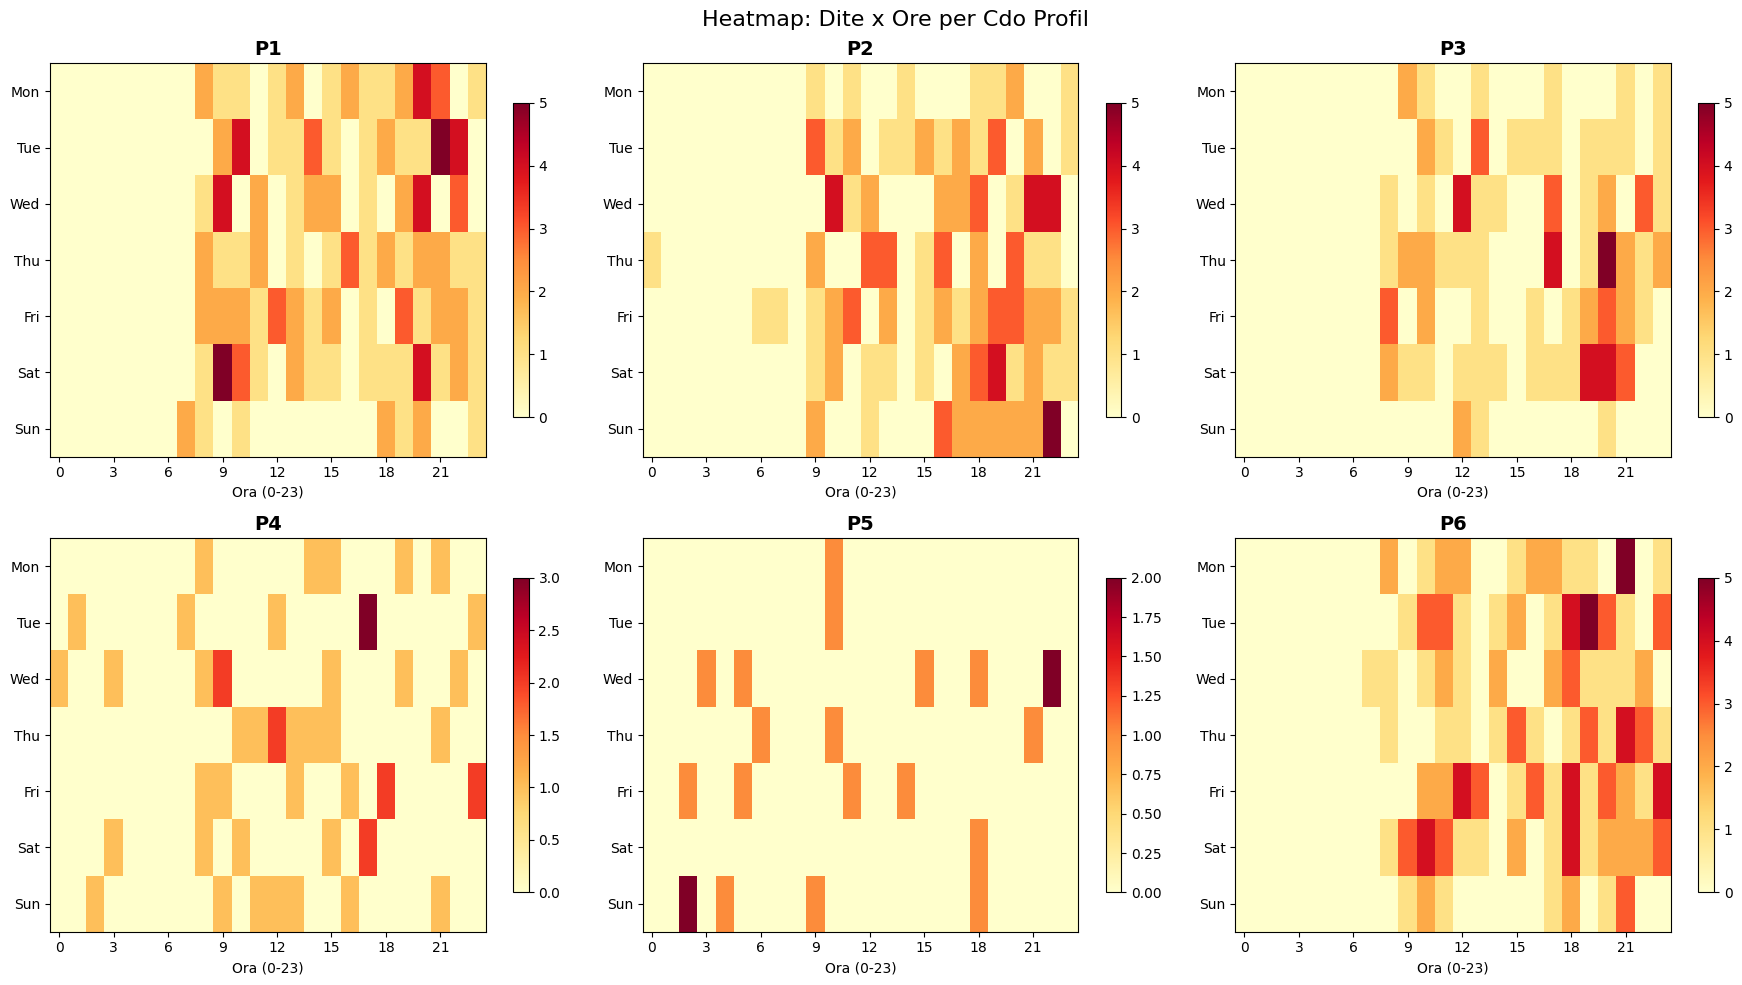

Heatmap e ruajtur ne figurat/V4_heatmap_dite_ore.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

base = r"C:\Users\Laura Biba\Desktop\OSINT Research\profile"
profiles = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
days_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Heatmap: Dite x Ore per Cdo Profil', fontsize=16)

for i, profile in enumerate(profiles):
    ax = axes[i//3][i%3]
    df = pd.read_csv(os.path.join(base, profile, 'timestamps.csv'))
    
    heatmap_data = np.zeros((7, 24))
    for _, row in df.iterrows():
        day_idx = days_order.index(row['weekday'])
        heatmap_data[day_idx][int(row['hour'])] += 1
    
    im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
    ax.set_title(f'{profile}', fontsize=14, fontweight='bold')
    ax.set_yticks(range(7))
    ax.set_yticklabels(days_order)
    ax.set_xlabel('Ora (0-23)')
    ax.set_xticks(range(0, 24, 3))
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(base, '..', 'figurat', 'V4_heatmap_dite_ore.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap e ruajtur ne figurat/V4_heatmap_dite_ore.png")